**LAB 6: MNIST Dataset Training Model**

This Lab will use the MNIST Dataset to build, train, and evaluate a CNN model. This lab will also preprocess data and visualize results.
This lab will use the MNIST dataset which is a collection of handwritten numerical images with a range of 0 to 9. The datset contains 60,000 training images with 10,000 testing images. Each image has been normalized to be a size of 28x28 pixels.


**IMPORTS**

In [59]:
import json
import numpy as np
import pandas as pd
from collections import OrderedDict
import torch
import torchvision
from torch import nn, optim
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models, datasets
from torchsummary import summary
from PIL import Image
import matplotlib.pyplot as plt
import memory_profiler  # conda install -c anaconda memory_profiler  |  conda install -c conda-forge memory_profiler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import os

In [30]:
root_dir = './data'

# Create the directory if it doesn't exist
os.makedirs(root_dir, exist_ok=True)

# Load the MNIST dataset
mnist_dataset = datasets.MNIST(root=root_dir, train=True, download=True, transform=None)

# Iterate through the dataset and save images
for index, (image, label) in enumerate(mnist_dataset):
    # Construct the file name with leading zeros
    file_name = f"{index:05d}.jpg"
    
    # Construct the full path to save the image
    file_path = os.path.join(root_dir, file_name)
    
    # Save the image as JPG
    image.save(file_path)



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 8109738.78it/s] 


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 370659.78it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 3696398.52it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<?, ?it/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



In [32]:
print(f"Successfully saved {len(mnist_dataset)} images to {root_dir}")

Successfully saved 60000 images to ./data


In [40]:
#We will tranform the dataset into a tensor type
data_transform = transforms.ToTensor()
#directory to save the transformed data
root_dir = './data/transformed'
#restoring the dataset with the new transformations
mnist_dataset = datasets.MNIST(root=root_dir, train=True, download=True, transform=data_transform)

#code to verify the transformation of the data by cheking its type and verifying the data is of size 28x28
image, label = mnist_dataset[0]
print(type(image)) 
print(image.shape) 

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:00<00:00, 13292666.17it/s]


Extracting ./data/transformed\MNIST\raw\train-images-idx3-ubyte.gz to ./data/transformed\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 380099.13it/s]


Extracting ./data/transformed\MNIST\raw\train-labels-idx1-ubyte.gz to ./data/transformed\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 3737228.81it/s]


Extracting ./data/transformed\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data/transformed\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 4541246.43it/s]

Extracting ./data/transformed\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data/transformed\MNIST\raw

<class 'torch.Tensor'>
torch.Size([1, 28, 28])


With the tranformations done to our dataset I will now create a dataloader to prepare the data to be used in batches.

In [63]:
BATCH_SIZE = 64
#memory profiler to view the memory usage
mem = memory_profiler.memory_usage()[0]
# Define the size of training and validation sets
train_size = int(0.8 * len(mnist_dataset))  # 80% for training
valid_size = len(mnist_dataset) - train_size  # 20% for validation

# Split the dataset into training and validation sets
train_dataset, valid_dataset = random_split(mnist_dataset, [train_size, valid_size])


train_loader = torch.utils.data.DataLoader(train_dataset,          # our raw data
                                           batch_size=BATCH_SIZE,  # the size of batches we want the dataloader to return
                                           shuffle=True,           # shuffle our data before batching
                                           drop_last=False)        # don't drop the last batch even if it's smaller than batch_size

valid_loader = torch.utils.data.DataLoader(valid_dataset,          # our raw data
                                           batch_size=BATCH_SIZE,  # the size of batches we want the dataloader to return
                                           shuffle=False,           # shuffle our data before batching
                                           drop_last=False)        # don't drop the last batch even if it's smaller than batch_size
print(f"Memory consumed: {memory_profiler.memory_usage()[0] - mem:.0f} mb")

Memory consumed: 1 mb


With the dataloader created we will load the dataloader with a batch of data to view the changes in memory usage. 

In [79]:
mem = memory_profiler.memory_usage()[0]
imgs, targets = next(iter(train_loader))
print(f"Training Dataset")
print(f"       # of batches: {len(train_loader)}")
print(f"    Image data type: {type(imgs)}")
print(f"   Image batch size: {imgs.shape}")  # dimensions are (batch size, image channels, image height, image width)
print(f"  Target batch size: {targets.shape}")
print(f"       Batch memory: {memory_profiler.memory_usage()[0] - mem:.2f} mb")  # memory usage after loading batch

mem = memory_profiler.memory_usage()[0]
imgs, targets = next(iter(valid_loader))
print(f"Valid Dataset")
print(f"       # of batches: {len(valid_loader)}")
print(f"    Image data type: {type(imgs)}")
print(f"   Image batch size: {imgs.shape}")  # dimensions are (batch size, image channels, image height, image width)
print(f"  Target batch size: {targets.shape}")
print(f"       Batch memory: {memory_profiler.memory_usage()[0] - mem:.2f} mb")

Training Dataset
       # of batches: 750
    Image data type: <class 'torch.Tensor'>
   Image batch size: torch.Size([64, 1, 28, 28])
  Target batch size: torch.Size([64])
       Batch memory: 1.94 mb
Valid Dataset
       # of batches: 188
    Image data type: <class 'torch.Tensor'>
   Image batch size: torch.Size([64, 1, 28, 28])
  Target batch size: torch.Size([64])
       Batch memory: -0.37 mb


Below is an example of a batch of data that has been loaded into the dataloader for training.

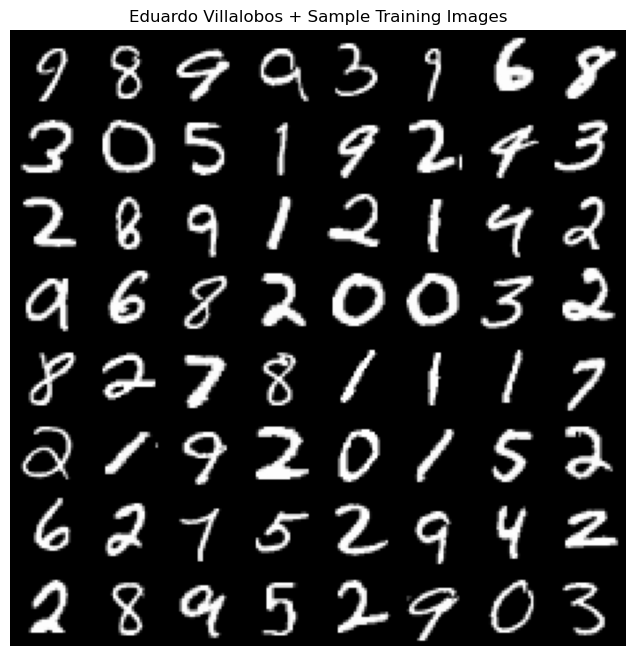

In [68]:
sample_batch = next(iter(train_loader))
plt.figure(figsize=(10, 8)); plt.axis("off"); plt.title("Eduardo Villalobos + Sample Training Images")
plt.imshow(np.transpose(make_grid(sample_batch[0], padding=1, normalize=True),(1,2,0)));

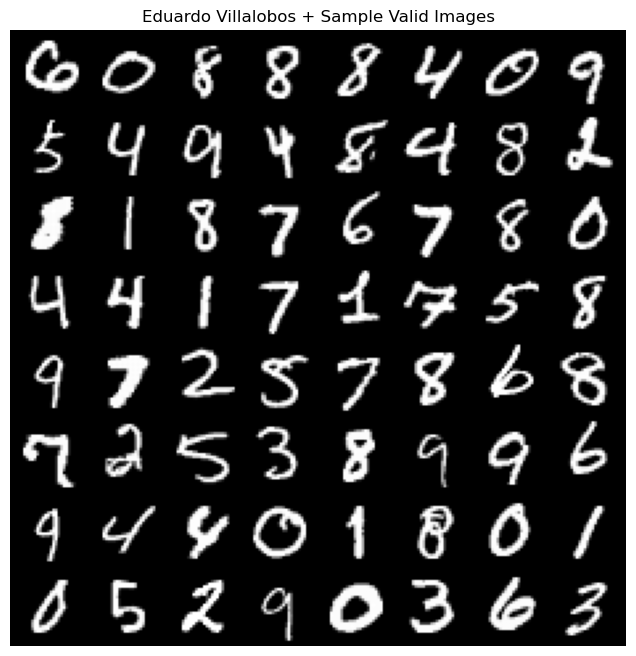

In [70]:
sample_batch = next(iter(valid_loader))
plt.figure(figsize=(10, 8)); plt.axis("off"); plt.title("Eduardo Villalobos + Sample Valid Images")
plt.imshow(np.transpose(make_grid(sample_batch[0], padding=1, normalize=True),(1,2,0)));

With the dataset ready for training I will now create a CNN model and trainer to train the dataset.

In [103]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Conv Layer 1
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Pooling 1
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Conv Layer 2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Pooling 2
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),  # Fully Connected Layer
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout for regularization
            nn.Linear(128, 10)  # Output Layer (10 classes for digits 0-9)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)  # Pass through Conv layers
        x = torch.flatten(x, 1)  # Flatten for FC layer
        x = self.fc_layers(x)  # Pass through Fully Connected layers
        return x


In [112]:
def train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = {"train_loss": [], "valid_loss": [], "valid_accuracy": []}

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()  # Reset gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # Evaluate on validation set
        model.eval()
        running_valid_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)  # Compute validation loss
                running_valid_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_valid_loss = running_valid_loss / len(valid_loader)
        valid_accuracy = 100 * correct / total

        # Store results in dictionary
        history["train_loss"].append(avg_train_loss)
        history["valid_loss"].append(avg_valid_loss)
        history["valid_accuracy"].append(valid_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, "
              f"Valid Loss: {avg_valid_loss:.4f}, Valid Accuracy: {valid_accuracy:.2f}%")

    print("Training Complete!")
    return history 

We will now train the model using a cross-entropy loss function and an Adam optimizer

In [117]:
# Define and train model
model = CNNModel()

criterion = nn.CrossEntropyLoss()  # Cross-Entropy Loss for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

#Train the model using the trainer function with 75 epochs
results = train_model(model, criterion, optimizer, train_loader, valid_loader, 75)

Epoch [1/75], Train Loss: 0.3450, Valid Loss: 0.0881, Valid Accuracy: 97.32%
Epoch [2/75], Train Loss: 0.1280, Valid Loss: 0.0598, Valid Accuracy: 98.23%
Epoch [3/75], Train Loss: 0.0966, Valid Loss: 0.0538, Valid Accuracy: 98.56%
Epoch [4/75], Train Loss: 0.0805, Valid Loss: 0.0447, Valid Accuracy: 98.83%
Epoch [5/75], Train Loss: 0.0684, Valid Loss: 0.0438, Valid Accuracy: 98.70%
Epoch [6/75], Train Loss: 0.0584, Valid Loss: 0.0452, Valid Accuracy: 98.89%
Epoch [7/75], Train Loss: 0.0536, Valid Loss: 0.0393, Valid Accuracy: 98.90%
Epoch [8/75], Train Loss: 0.0480, Valid Loss: 0.0398, Valid Accuracy: 99.04%
Epoch [9/75], Train Loss: 0.0428, Valid Loss: 0.0390, Valid Accuracy: 99.00%
Epoch [10/75], Train Loss: 0.0385, Valid Loss: 0.0396, Valid Accuracy: 98.94%
Epoch [11/75], Train Loss: 0.0357, Valid Loss: 0.0407, Valid Accuracy: 99.05%
Epoch [12/75], Train Loss: 0.0329, Valid Loss: 0.0384, Valid Accuracy: 99.02%
Epoch [13/75], Train Loss: 0.0306, Valid Loss: 0.0408, Valid Accuracy: 99

With our dataset fully trained it is now time to display the results. I chose to display training loss over epoch,validation loss over epoch, validation accuracy over epoch, and predicted vs actual value graphs. 

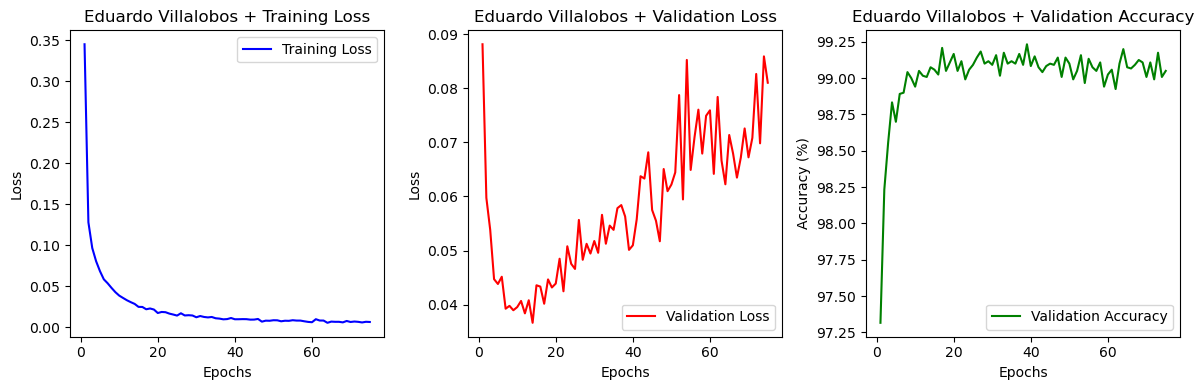

In [121]:
def plot_training_results(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Plot Training Loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Training Loss", color='blue')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Eduardo Villalobos + Training Loss")
    plt.legend()

    # Plot Validation Loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["valid_loss"], label="Validation Loss", color='red')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Eduardo Villalobos + Validation Loss")
    plt.legend()

    # Plot Validation Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["valid_accuracy"], label="Validation Accuracy", color='green')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Eduardo Villalobos + Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function after training
plot_training_results(results)

In [131]:
def plot_predicted_vs_actual(model, valid_loader, device):

    model.eval()
    actual_values = []
    predicted_values = []
    
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            actual_values.extend(labels.cpu().numpy())  # Actual labels (true values)
            predicted_values.extend(preds.cpu().numpy())  # Predicted labels (model output)

    # Plot Predicted vs Actual (Numerical values)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual_values, predicted_values, alpha=0.6, color='purple')
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Eduardo Villalobos + Predicted vs Actual Values")
    plt.grid(True)
    plt.show()

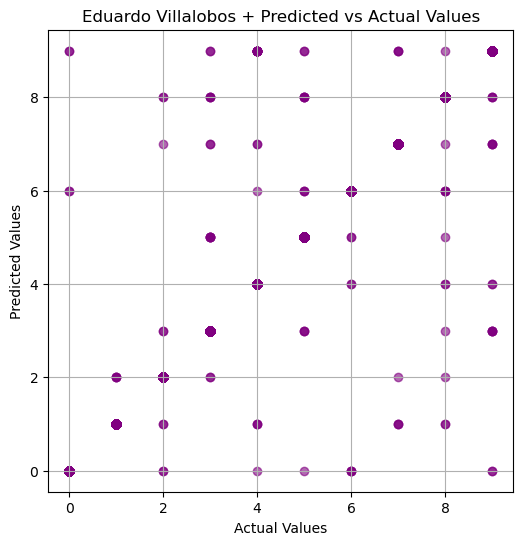

In [133]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plot_predicted_vs_actual(model, valid_loader, device)

Saving the model to a pt file.

In [137]:
PATH = "models/mnist_cnn_model.pt"
torch.save(model, PATH)